In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Загружаем нашу витрину
df = pd.read_csv('../data/processed/fact_loan_status_monthly.csv', parse_dates=['report_date'])

print(f"Загружено записей: {len(df):,}")
print(f"Уникальных кредитов: {df['loan_id'].nunique():,}")
print(f"Диапазон дат: {df['report_date'].min().date()} — {df['report_date'].max().date()}")
print(f"\nПервые 5 строк:")
df.head()

Загружено записей: 10,092
Уникальных кредитов: 700
Диапазон дат: 2024-01-31 — 2026-08-31

Первые 5 строк:


,loan_id,client_id,product_name,report_date,year_month,initial_amount,outstanding_principal,cum_scheduled,cum_paid,overdue_amount,dpd,ifrs9_stage
0,LN_00001,CLT_00430,POS-кредит,2025-07-31,2025-07,1599550,1599550.00,0.00,0.00,0.00,0,1
1,LN_00001,CLT_00430,POS-кредит,2025-08-31,2025-08,1599550,1599550.00,294210.56,294210.56,0.00,0,1
2,LN_00001,CLT_00430,POS-кредит,2025-09-30,2025-09,1599550,1332958.33,583817.97,446917.68,136900.29,27,1
3,LN_00001,CLT_00430,POS-кредит,2025-10-31,2025-10,1599550,1066366.67,868822.23,1012323.05,0.00,0,1
4,LN_00001,CLT_00430,POS-кредит,2025-11-30,2025-11,1599550,799775.00,1149223.34,1012323.05,136900.29,27,1


In [3]:
print("=" * 60)
print("ОТЧЕТ О КАЧЕСТВЕ ДАННЫХ")
print("=" * 60)

# 1. Проверка на пропуски
print("\n1. Пропущенные значения:")
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("   ✓ Пропусков нет")
else:
    print(null_counts[null_counts > 0])

# 2. Проверка первичного ключа (уникальность кредит + дата)
print("\n2. Уникальность записей (loan_id + report_date):")
duplicates = df.duplicated(subset=['loan_id', 'report_date']).sum()
if duplicates == 0:
    print("   ✓ Дубликатов нет")
else:
    print(f"   ✗ Найдено дубликатов: {duplicates}")

# 3. Проверка бизнес-правил
print("\n3. Проверка бизнес-правил:")
# Остаток долга не должен быть отрицательным
negative_balance = (df['outstanding_principal'] < 0).sum()
print(f"   {'✓' if negative_balance == 0 else '✗'} Отрицательных остатков: {negative_balance}")

# DPD не должен быть отрицательным
negative_dpd = (df['dpd'] < 0).sum()
print(f"   {'✓' if negative_dpd == 0 else '✗'} Отрицательных DPD: {negative_dpd}")

# Стадия должна быть 1, 2 или 3
invalid_stage = (~df['ifrs9_stage'].isin([1, 2, 3])).sum()
print(f"   {'✓' if invalid_stage == 0 else '✗'} Некорректных стадий: {invalid_stage}")

# 4. Логическая проверка: если стадия 3, то DPD должен быть > 90
stage3_check = df[df['ifrs9_stage'] == 3]['dpd'].min()
print(f"   {'✓' if stage3_check > 90 else '✗'} Мин. DPD для Стадии 3: {stage3_check} (должно быть > 90)")

ОТЧЕТ О КАЧЕСТВЕ ДАННЫХ

1. Пропущенные значения:
   ✓ Пропусков нет

2. Уникальность записей (loan_id + report_date):
   ✓ Дубликатов нет

3. Проверка бизнес-правил:
   ✓ Отрицательных остатков: 0
   ✓ Отрицательных DPD: 0
   ✓ Некорректных стадий: 0
   ✓ Мин. DPD для Стадии 3: 91 (должно быть > 90)


Анализ портфеля на дату: 2026-08-31
Всего активных кредитов: 325

Распределение по стадиям МСФО 9:
  Стадия 1: 180 кредитов (55.4%)
  Стадия 2: 134 кредитов (41.2%)
  Стадия 3: 11 кредитов (3.4%)


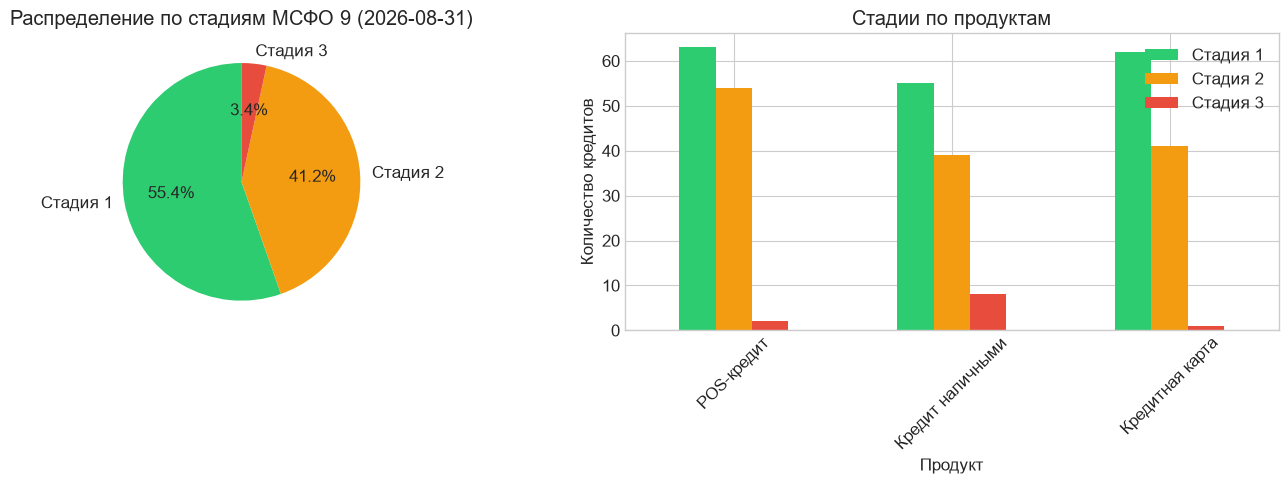

In [4]:
# Анализируем распределение по стадиям на последнюю отчетную дату
latest_date = df['report_date'].max()
df_latest = df[df['report_date'] == latest_date]

print(f"Анализ портфеля на дату: {latest_date.date()}")
print(f"Всего активных кредитов: {len(df_latest)}")

# Распределение по стадиям
stage_dist = df_latest['ifrs9_stage'].value_counts().sort_index()
print("\nРаспределение по стадиям МСФО 9:")
for stage, count in stage_dist.items():
    pct = count / len(df_latest) * 100
    print(f"  Стадия {stage}: {count} кредитов ({pct:.1f}%)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Круговая диаграмма
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].pie(stage_dist.values, labels=[f'Стадия {s}' for s in stage_dist.index], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title(f'Распределение по стадиям МСФО 9 ({latest_date.date()})')

# Столбчатая диаграмма по продуктам
product_stage = pd.crosstab(df_latest['product_name'], df_latest['ifrs9_stage'])
product_stage.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Стадии по продуктам')
axes[1].set_xlabel('Продукт')
axes[1].set_ylabel('Количество кредитов')
axes[1].legend([f'Стадия {s}' for s in [1, 2, 3]])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

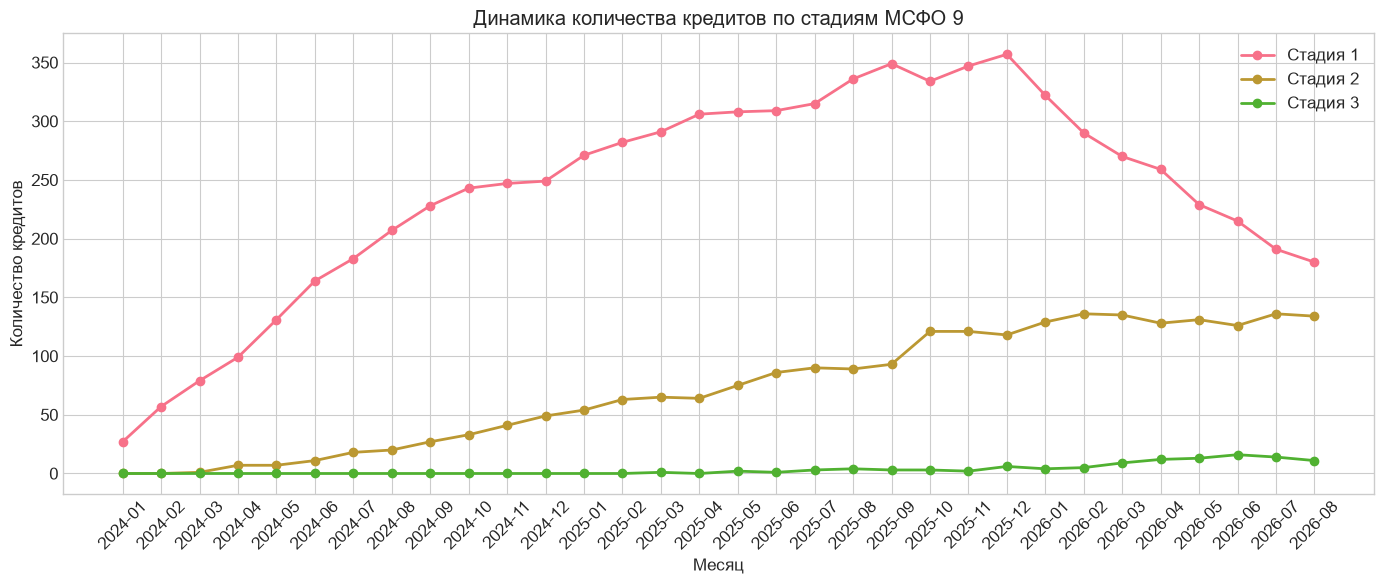

In [5]:
# Тренд количества кредитов по стадиям по месяцам
monthly_stages = df.groupby(['year_month', 'ifrs9_stage']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))

for stage in [1, 2, 3]:
    if stage in monthly_stages.columns:
        ax.plot(monthly_stages.index, monthly_stages[stage], 
                marker='o', linewidth=2, label=f'Стадия {stage}')

ax.set_title('Динамика количества кредитов по стадиям МСФО 9')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество кредитов')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

МАТРИЦА МИГРАЦИИ СТАДИЙ МСФО 9

Абсолютные значения (количество переходов):
В стадию      1     2   3
Из стадии                
1          6558   660   0
2           416  1619  46
3             1    29  63

Вероятности переходов (%):
В стадию      1     2     3
Из стадии                  
1          90.9   9.1   0.0
2          20.0  77.8   2.2
3           1.1  31.2  67.7


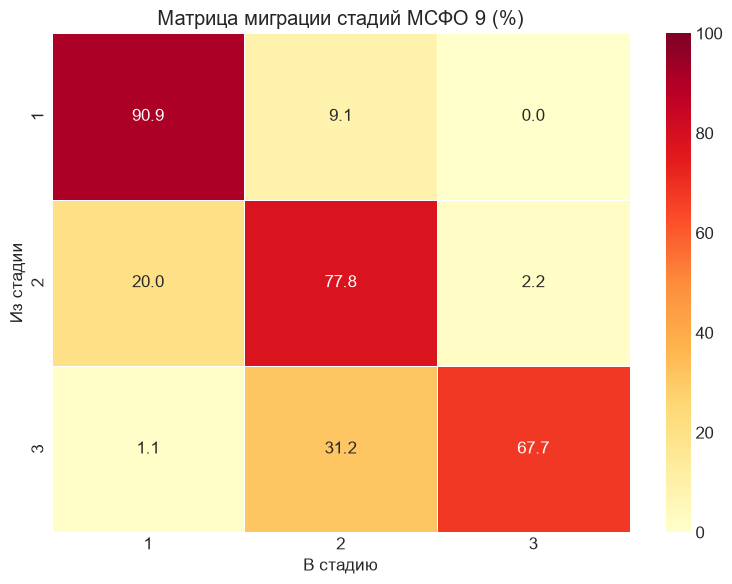

In [6]:
def build_migration_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    Строит матрицу миграции стадий.
    Показывает, сколько кредитов перешло из одной стадии в другую за месяц.
    """
    # Сортируем по кредиту и дате
    df_sorted = df.sort_values(['loan_id', 'report_date'])
    
    # Для каждого кредита находим предыдущую стадию
    df_sorted['prev_stage'] = df_sorted.groupby('loan_id')['ifrs9_stage'].shift(1)
    
    # Убираем первые записи (у них нет предыдущей стадии)
    df_transitions = df_sorted.dropna(subset=['prev_stage']).copy()
    df_transitions['prev_stage'] = df_transitions['prev_stage'].astype(int)
    
    # Строим матрицу переходов
    migration = pd.crosstab(
        df_transitions['prev_stage'], 
        df_transitions['ifrs9_stage'],
        rownames=['Из стадии'],
        colnames=['В стадию']
    )
    
    # Добавляем отсутствующие стадии (если их нет)
    for stage in [1, 2, 3]:
        if stage not in migration.index:
            migration.loc[stage] = 0
        if stage not in migration.columns:
            migration[stage] = 0
    
    migration = migration.sort_index(axis=0).sort_index(axis=1)
    
    return migration

# Строим матрицу миграции
migration_matrix = build_migration_matrix(df)

print("=" * 60)
print("МАТРИЦА МИГРАЦИИ СТАДИЙ МСФО 9")
print("=" * 60)
print("\nАбсолютные значения (количество переходов):")
print(migration_matrix)

# В процентах (вероятность перехода)
migration_pct = migration_matrix.div(migration_matrix.sum(axis=1), axis=0) * 100
print("\nВероятности переходов (%):")
print(migration_pct.round(1))

# Визуализация
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(migration_pct, annot=True, fmt='.1f', cmap='YlOrRd', 
            ax=ax, linewidths=0.5, vmin=0, vmax=100)
ax.set_title('Матрица миграции стадий МСФО 9 (%)')
ax.set_xlabel('В стадию')
ax.set_ylabel('Из стадии')
plt.tight_layout()
plt.show()

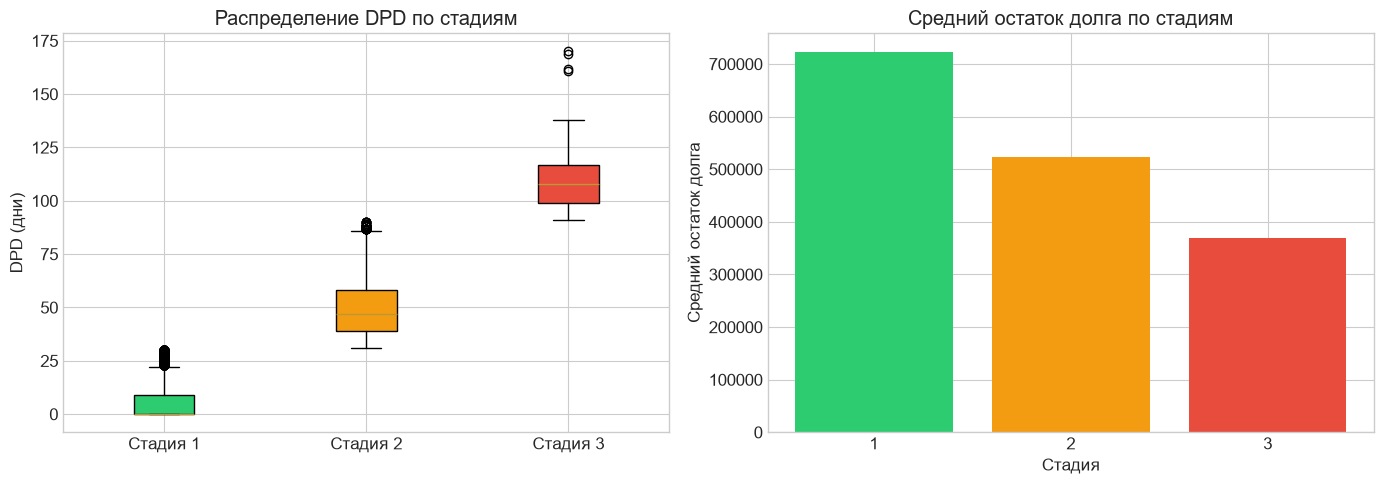


Статистика просрочки по стадиям:
                dpd             overdue_amount              
               mean median  max           mean           sum
ifrs9_stage                                                 
1              5.45    0.0   30       15458.87  1.186468e+08
2             50.49   47.0   90       77944.47  1.798958e+08
3            111.00  108.0  170      142918.30  1.557809e+07


In [7]:
# Анализ распределения DPD по стадиям
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot DPD по стадиям
stage_data = [df[df['ifrs9_stage'] == s]['dpd'] for s in [1, 2, 3]]
# Исправлено: используем tick_labels вместо labels (для matplotlib >= 3.9)
bp = axes[0].boxplot(stage_data, tick_labels=['Стадия 1', 'Стадия 2', 'Стадия 3'], patch_artist=True)

# Добавляем цвета для каждой стадии
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    
axes[0].set_title('Распределение DPD по стадиям')
axes[0].set_ylabel('DPD (дни)')

# Средний остаток долга по стадиям
avg_balance = df.groupby('ifrs9_stage')['outstanding_principal'].mean()
axes[1].bar(avg_balance.index, avg_balance.values, color=colors)
axes[1].set_title('Средний остаток долга по стадиям')
axes[1].set_xlabel('Стадия')
axes[1].set_ylabel('Средний остаток долга')
axes[1].set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

# Статистика по просрочке
print("\nСтатистика просрочки по стадиям:")
stats = df.groupby('ifrs9_stage').agg({
    'dpd': ['mean', 'median', 'max'],
    'overdue_amount': ['mean', 'sum']
}).round(2)
print(stats)